<a href="https://colab.research.google.com/github/Selvi-231801161/GenAI-Laboratory/blob/main/GenAI_EXP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch [1/10] D Loss: 0.1312 G Loss: 2.5360
Epoch [2/10] D Loss: 0.4075 G Loss: 1.8304
Epoch [3/10] D Loss: 0.4563 G Loss: 2.0586
Epoch [4/10] D Loss: 0.7479 G Loss: 1.4882
Epoch [5/10] D Loss: 0.3592 G Loss: 2.1866
Epoch [6/10] D Loss: 0.3813 G Loss: 2.0830
Epoch [7/10] D Loss: 0.8211 G Loss: 1.5599
Epoch [8/10] D Loss: 0.9090 G Loss: 1.6603
Epoch [9/10] D Loss: 0.7369 G Loss: 1.3723
Epoch [10/10] D Loss: 0.3952 G Loss: 2.0591


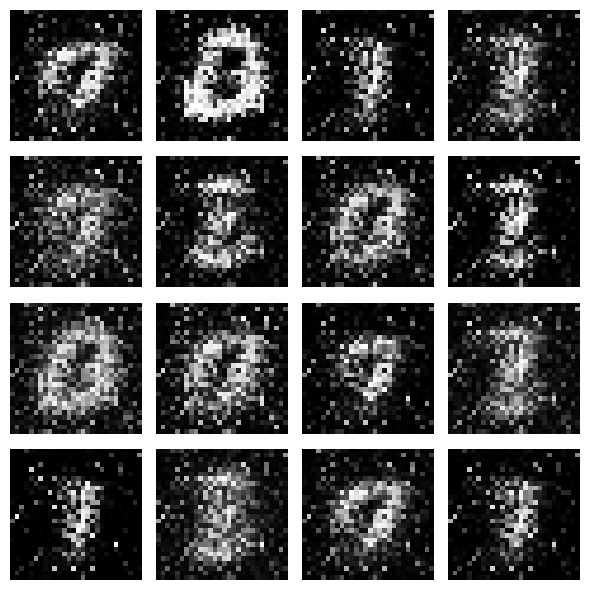

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train, _), (_, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

batch_size = 64
noise_dim = 100
epochs = 10

dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(batch_size)

generator = keras.Sequential([
    keras.layers.Input(shape=(noise_dim,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(28 * 28 * 1, activation='tanh'),
    keras.layers.Reshape((28, 28, 1))
])

discriminator = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

loss_fn = keras.losses.BinaryCrossentropy()
g_optimizer = keras.optimizers.Adam(learning_rate=0.0002)
d_optimizer = keras.optimizers.Adam(learning_rate=0.0002)

for epoch in range(epochs):
    for real_images in dataset:
        batch_size_now = real_images.shape[0]

        real_labels = tf.ones((batch_size_now, 1))
        fake_labels = tf.zeros((batch_size_now, 1))

        noise = tf.random.normal((batch_size_now, noise_dim))
        fake_images = generator(noise, training=True)

        with tf.GradientTape() as tape:
            real_output = discriminator(real_images, training=True)
            fake_output = discriminator(fake_images, training=True)

            real_loss = loss_fn(real_labels, real_output)
            fake_loss = loss_fn(fake_labels, fake_output)
            d_loss = real_loss + fake_loss

        d_gradients = tape.gradient(d_loss, discriminator.trainable_variables)
        d_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))

        noise = tf.random.normal((batch_size_now, noise_dim))

        with tf.GradientTape() as tape:
            generated_images = generator(noise, training=True)
            output = discriminator(generated_images, training=True)
            g_loss = loss_fn(real_labels, output)

        g_gradients = tape.gradient(g_loss, generator.trainable_variables)
        g_optimizer.apply_gradients(zip(g_gradients, generator.trainable_variables))

    print(f"Epoch [{epoch+1}/{epochs}] D Loss: {d_loss.numpy():.4f} G Loss: {g_loss.numpy():.4f}")

noise = tf.random.normal((16, noise_dim))
generated_images = generator(noise, training=False)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow((generated_images[i, :, :, 0] + 1) / 2, cmap='gray')
    ax.axis("off")

plt.tight_layout()
plt.show()